In [1]:
import glob

folder = "../outputs/planning_scale/instruct/*"
glob.glob(folder)

['../outputs/planning_scale/instruct/prompt_1',
 '../outputs/planning_scale/instruct/prompt_10',
 '../outputs/planning_scale/instruct/prompt_11',
 '../outputs/planning_scale/instruct/prompt_12',
 '../outputs/planning_scale/instruct/prompt_13',
 '../outputs/planning_scale/instruct/prompt_14',
 '../outputs/planning_scale/instruct/prompt_15',
 '../outputs/planning_scale/instruct/prompt_16',
 '../outputs/planning_scale/instruct/prompt_17',
 '../outputs/planning_scale/instruct/prompt_18',
 '../outputs/planning_scale/instruct/prompt_19',
 '../outputs/planning_scale/instruct/prompt_2',
 '../outputs/planning_scale/instruct/prompt_20',
 '../outputs/planning_scale/instruct/prompt_21',
 '../outputs/planning_scale/instruct/prompt_22',
 '../outputs/planning_scale/instruct/prompt_23',
 '../outputs/planning_scale/instruct/prompt_24',
 '../outputs/planning_scale/instruct/prompt_25',
 '../outputs/planning_scale/instruct/prompt_26',
 '../outputs/planning_scale/instruct/prompt_27',
 '../outputs/planning_

In [2]:
for f in glob.glob(folder):
    token_files = glob.glob(f + "/*")
    print(f, len(token_files))

../outputs/planning_scale/instruct/prompt_1 49
../outputs/planning_scale/instruct/prompt_10 18
../outputs/planning_scale/instruct/prompt_11 31
../outputs/planning_scale/instruct/prompt_12 40
../outputs/planning_scale/instruct/prompt_13 45
../outputs/planning_scale/instruct/prompt_14 23
../outputs/planning_scale/instruct/prompt_15 44
../outputs/planning_scale/instruct/prompt_16 17
../outputs/planning_scale/instruct/prompt_17 33
../outputs/planning_scale/instruct/prompt_18 49
../outputs/planning_scale/instruct/prompt_19 48
../outputs/planning_scale/instruct/prompt_2 15
../outputs/planning_scale/instruct/prompt_20 42
../outputs/planning_scale/instruct/prompt_21 19
../outputs/planning_scale/instruct/prompt_22 45
../outputs/planning_scale/instruct/prompt_23 37
../outputs/planning_scale/instruct/prompt_24 42
../outputs/planning_scale/instruct/prompt_25 49
../outputs/planning_scale/instruct/prompt_26 49
../outputs/planning_scale/instruct/prompt_27 49
../outputs/planning_scale/instruct/prompt_

In [3]:
import json

timings = {}

for fi in glob.glob(folder):
    token_files = glob.glob(fi + "/*")
    for tf in token_files:
        metadata_file = tf + "/metadata.json"
        with open(metadata_file, "r") as f:
            metadata = json.load(f)
        prompt_idx = fi.split("prompt_")[-1]
        token_idx = tf.split("token_")[-1]
        timings[(prompt_idx, token_idx)] = metadata["timings"]

In [4]:
len(timings)

1493

In [5]:
timings[timings.keys().__iter__().__next__()]

{'circuit_discovery_s': 35.06870836671442,
 'clustering_s_gather': 2.759759592823684,
 'clustering_s_neuronpedia': 0.21460858918726444,
 'clustering_s': 2.9743926199153066,
 'steering_sweep_s': 10.599514462053776,
 'per_position_total_s': 231.81886095367372,
 'per_position_checked': 90.0,
 'total_s': 280.4652407374233}

In [6]:
## get average time per token.
all_times = [x["total_s"] for x in timings.values()]
avg_time = sum(all_times) / len(all_times)
avg_time

189.28963341045213

In [7]:
## get average time per file.
time_per_file = {}
for (prompt_idx, token_idx), timing in timings.items():
    if prompt_idx not in time_per_file:
        time_per_file[prompt_idx] = 0
    time_per_file[prompt_idx] += timing["total_s"]

all_file_times = list(time_per_file.values())
avg_file_time = sum(all_file_times) / len(all_file_times)
avg_file_time

7065.235567045126

In [8]:
## max and min file time.
max_file_time = max(all_file_times)
min_file_time = min(all_file_times)
max_file_time, min_file_time

(13726.60478339903, 1441.8892484325916)

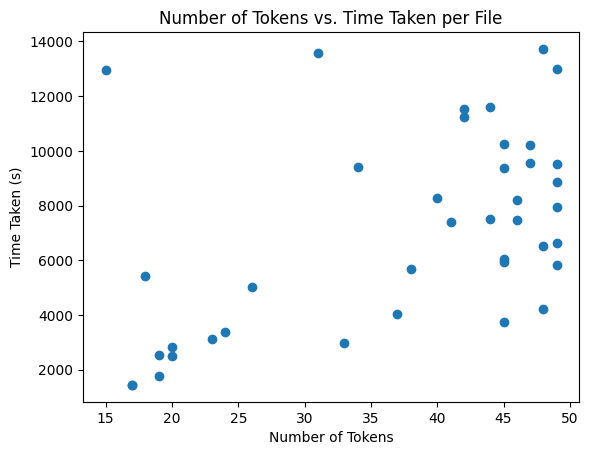

In [9]:
## get number of tokens vs. time consumed per file.
tokens_per_file = {}
for (prompt_idx, token_idx), timing in timings.items():
    if prompt_idx not in tokens_per_file:
        tokens_per_file[prompt_idx] = 0
    tokens_per_file[prompt_idx] += 1

import matplotlib.pyplot as plt
num_tokens = list(tokens_per_file.values())
plt.scatter(num_tokens, all_file_times)
plt.xlabel("Number of Tokens")
plt.ylabel("Time Taken (s)")
plt.title("Number of Tokens vs. Time Taken per File")
plt.show()

In [10]:
tokens_per_file, time_per_file

({'1': 49,
  '10': 18,
  '11': 31,
  '12': 40,
  '13': 45,
  '14': 23,
  '15': 44,
  '16': 17,
  '17': 33,
  '18': 49,
  '19': 48,
  '2': 15,
  '20': 42,
  '21': 19,
  '22': 45,
  '23': 37,
  '24': 42,
  '25': 49,
  '26': 49,
  '27': 49,
  '28': 48,
  '29': 45,
  '3': 44,
  '30': 49,
  '31': 45,
  '32': 20,
  '33': 20,
  '34': 41,
  '35': 26,
  '36': 46,
  '37': 24,
  '38': 38,
  '39': 34,
  '4': 17,
  '40': 46,
  '5': 45,
  '6': 48,
  '7': 47,
  '8': 19,
  '9': 47},
 {'1': 6614.187897713855,
  '10': 5417.353277905844,
  '11': 13582.775893894024,
  '12': 8278.252039960586,
  '13': 3729.5170588623732,
  '14': 3102.96792452503,
  '15': 11590.072455313988,
  '16': 1441.8892484325916,
  '17': 2980.6048469617963,
  '18': 12996.405636687763,
  '19': 4232.147251568735,
  '2': 12967.782033251598,
  '20': 11518.645256793126,
  '21': 2533.8291532173753,
  '22': 6045.212555104867,
  '23': 4043.701727947686,
  '24': 11238.019543022849,
  '25': 8857.232294638641,
  '26': 9518.049768685363,
  '27': 

In [11]:
import argparse
import ast
import glob
import json
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

def any_repeated_substring(s, min_repeats=5, max_sub_len=10):
    n = len(s)
    L = max_sub_len
    if n < L:
        return False
    counts = Counter(s[i : i + L] for i in range(n - L + 1))
    return any(v >= min_repeats for v in counts.values())


class Normalizer(ast.NodeTransformer):
    def __init__(self):
        self.var_map = {}
        self.func_map = {}
        self.class_map = {}

    def _rename(self, name, mapping):
        if name not in mapping:
            mapping[name] = f"id_{len(mapping)}"
        return mapping[name]

    def visit_Name(self, node):
        node.id = self._rename(node.id, self.var_map)
        return node

    def visit_arg(self, node):
        node.arg = self._rename(node.arg, self.var_map)
        return node

    def visit_FunctionDef(self, node):
        node.name = self._rename(node.name, self.func_map)
        self.generic_visit(node)
        return node

    def visit_ClassDef(self, node):
        node.name = self._rename(node.name, self.class_map)
        self.generic_visit(node)
        return node


def normalize_ast(code):
    try:
        tree = ast.parse(code)
        norm = Normalizer().visit(tree)
        ast.fix_missing_locations(norm)
        return norm
    except Exception:
        return None


def _is_ast_possible(code):
    try:
        extract = "def" + code.split("```python\n")[-1].split("def")[1]
        ast_tree = normalize_ast(extract)
        return ast_tree is not None
    except Exception:
        return False


def _downgrade_plan_to_degenerate(steered_text, original_ym=None):
    if original_ym is not None and original_ym in steered_text:
        return True

    stripped_text = steered_text.strip()
    if stripped_text == "":
        return False
    if not _is_ast_possible(steered_text):
        return True
    if " " not in stripped_text and len(stripped_text) >= 10:
        return True
    if any_repeated_substring(steered_text) and (
        original_ym == "return" or (original_ym != "return" and "return" not in steered_text)
    ):
        return True
    if original_ym == "return":
        return True
    return False


def _not_planning(steered_text, original_ym=None):
    if original_ym is not None and original_ym in steered_text:
        return True
    stripped_text = steered_text.strip()
    if stripped_text == "" or (" " not in stripped_text and len(stripped_text) >= 10):
        return True
    return False


def _classify_earliest_position_as_planning(steering_results, planning_analysis, max_coeff):
    ym_keys = list(planning_analysis.keys())
    new_planning_analysis = {}
    for y_m in ym_keys:
        new_verdict = planning_analysis[y_m]["final_label"]
        base_suffix = steering_results[y_m].get("base_text", "")

        relevant_steered = [
            e for e in steering_results[y_m]["steered"] if e.get("coeff", -999999) >= max_coeff
        ]
        all_degenerate = all(
            _downgrade_plan_to_degenerate(e.get("decoded_text", ""), y_m) for e in relevant_steered
        )
        all_not_planning = all(
            _not_planning(e.get("decoded_text", ""), y_m) for e in relevant_steered
        )
        base_ok = not base_suffix.startswith(y_m)

        if planning_analysis[y_m]["final_label"] == "Plan":
            if base_ok and not all_degenerate:
                new_verdict = "Not planning" if all_not_planning else "Plan"
            else:
                new_verdict = "Can't say"
        elif planning_analysis[y_m]["final_label"] == "Can't say":
            if base_ok and not all_degenerate and all_not_planning:
                new_verdict = "Not planning"

        new_planning_analysis[y_m] = {
            "original_verdict": planning_analysis[y_m]["final_label"],
            "new_verdict": new_verdict,
        }

    return new_planning_analysis

In [12]:
steering_results = "../outputs/planning_scale/instruct/prompt_1/token_109/earliest_position.json"
planning_analysis = "../outputs/planning_scale/instruct/prompt_1/token_109/earliest_position_planning_analysis.json"
with open(steering_results, "r") as f:
    steering_results = json.load(f)
with open(planning_analysis, "r") as f:
    planning_analysis = json.load(f)
classified = _classify_earliest_position_as_planning(
    steering_results, planning_analysis, max_coeff=-200
)

In [13]:
classified

{'in': {'original_verdict': "Can't say", 'new_verdict': "Can't say"},
 'return': {'original_verdict': 'Not planning', 'new_verdict': 'Not planning'},
 'if': {'original_verdict': 'Not planning', 'new_verdict': 'Not planning'},
 'int': {'original_verdict': 'Not planning', 'new_verdict': 'Not planning'},
 'for': {'original_verdict': 'Plan', 'new_verdict': 'Plan'},
 '+': {'original_verdict': 'Not planning', 'new_verdict': 'Not planning'},
 'i': {'original_verdict': 'Not planning', 'new_verdict': 'Not planning'}}

In [14]:
for fi in glob.glob(folder):
    token_files = glob.glob(fi + "/*")
    for tf in token_files:
        if os.path.exists(tf + "/earliest_position.json"):
            steering_results_file = tf + "/earliest_position.json"
            planning_analysis_file = tf + "/earliest_position_planning_analysis.json"
            with open(steering_results_file, "r") as f:
                steering_results = json.load(f)
            with open(planning_analysis_file, "r") as f:
                planning_analysis = json.load(f)
            classified = _classify_earliest_position_as_planning(
                steering_results, planning_analysis, max_coeff=-200
            )

            os.makedirs(
                    tf.replace("planning_scale", "planning_scale_classified_e"), exist_ok=True
                )
            with open(tf.replace("planning_scale", "planning_scale_classified_e") + "/updated_planning_analysis.json", "w") as f:
                json.dump(classified, f, indent = 4)

In [15]:
## count the number of "Plan" verdicts after verdict against whether pass or fail and also the y_ms encountered.
all_dict = {}
cs_dict = {}
np_dict = {}
for fi in glob.glob(folder):
    token_files = glob.glob(fi + "/*")
    prompt_idx = fi.split("_")[-1]
    li = []
    li_cs = []
    li_np = []
    for tf in token_files:
        tf_p = tf.replace("planning_scale", "planning_scale_classified_e") + "/updated_planning_analysis.json"
        if os.path.exists(tf_p):
            with open(tf_p, "r") as f:
                planning_analysis = json.load(f)
            for k, v in planning_analysis.items():
                if v["new_verdict"] == "Plan":
                    li.append(k)
                elif v["new_verdict"] == "Can't say":
                    li_cs.append(k)
                else:
                    li_np.append(k)
                
    all_dict[prompt_idx] = li
    cs_dict[prompt_idx] = li_cs
    np_dict[prompt_idx] = li_np
    
print(all_dict.keys())

dict_keys(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '5', '6', '7', '8', '9'])


In [16]:
with open("../data/external/all_examples_og_prompt_with_position_info_and_success_V2.json", "r") as f:
    data = json.load(f)

In [18]:
import pandas as pd 

df_dict_li = []
for k, v in all_dict.items():
    unique_yms = list(set(v))
    tot = len(v)
    tot_cs = len(cs_dict[k])
    tot_np = len(np_dict[k])
    ki = int(k)
    passed = data[ki]["instruct_pass"]
    df_dict_li.append({
        "prompt": ki,
        "unique_yms": unique_yms,
        "total_plan_events": tot,
        "success": "Pass" if passed else "Fail",
        # "total_cant_say_events": tot_cs,
        # "total_not_planning_events": tot_np
    })

df_dict = pd.DataFrame(df_dict_li)
df_dict

,prompt,unique_yms,total_plan_events,success
0,1,"[for, %, +, int, return]",19,Pass
1,10,[*],3,Pass
2,11,"[return, replace, if, 1]",6,Pass
3,12,"[return, (), if]",6,Pass
4,13,"[1, return, %]",6,Fail
5,14,"[-, 1, *, int]",9,Pass
6,15,"[(), if, int, -, return, +]",63,Fail
7,16,"[return, *]",7,Pass
8,17,"[//, *]",6,Fail
9,18,"[j, if, int, ], return, []",20,Pass


In [20]:
df_dict.groupby("success")["total_plan_events"].describe()

,count,mean,std,min,25%,50%,75%,max
success,,,,,,,,
Fail,16.0,19.312500,16.898595,4.0,6.0,11.5,33.00,63.0
Pass,24.0,10.666667,8.820267,1.0,5.0,7.0,18.25,38.0
